## **Import Data**

In [2]:
import pandas as pd

train_path = '.\\train.csv'
train_df = pd.read_csv(train_path)
train_df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB


| Column Name         | Description                                                                           |
|---------------------|---------------------------------------------------------------------------------------|
| id                  | 고객에 대한 고유 ID입니다.                                                            |
| Gender              | 고객의 성별을 나타냅니다.                                                              |
| Age                 | 고객의 나이입니다.                                                                    |
| Driving License     | 운전면허가 있는지를 나타냅니다. 0은 운전면허가 없음을, 1은 이미 운전면허가 있는 것을 의미합니다. |
| Region Code         | 고객이 속한 지역의 고유 코드입니다.                                                    |
| Previously Insured  | 자동차 보험에 이미 가입한 고객인지를 나타냅니다. 0은 아직 가입하지 않은 것을, 1은 이미 가입한 것을 의미합니다. |
| Vehicle Age         | 차량의 연식을 나타냅니다.                                                              |
| Vehicle Damage      | 고객의 차량이 과거에 손상되었는지를 나타냅니다. 0은 차량이 손상되지 않았음을, 1은 과거에 손상되었음을 의미합니다. |
| Annual Premium      | 고객이 연간 보험료로 지불해야 할 금액입니다.                                          |
| Policy Sales Channel| 고객에게 연락하는데 사용되는 채널에 대한 익명화된 코드입니다.                               |
| Vintage             | 고객이 회사와 연관된 기간(일 수)입니다.                                                 |
| Response            | 자동차 보험에 관심이 있는지 여부를 나타냅니다. 0은 관심이 없음을, 1은 관심이 있음을 의미합니다. |


## **Check Data Type**

In [4]:
data_types = train_df.dtypes

objects = []
for idx in data_types.index:
    data_type = data_types[idx]

    if data_type == 'object':
        objects.append(idx)
        print(train_df[idx].value_counts())
        print()

Gender
Male      206089
Female    175020
Name: count, dtype: int64

Vehicle_Age
1-2 Year     200316
< 1 Year     164786
> 2 Years     16007
Name: count, dtype: int64

Vehicle_Damage
Yes    192413
No     188696
Name: count, dtype: int64



In [5]:
# Gender
gender_mapping = {'Female': 0,
                  'Male': 1}
train_df['Gender'] = train_df['Gender'].map(gender_mapping)

In [6]:
# Vehicle Age
vehicle_age_mapping = {'< 1 Year': 0,
                       '1-2 Year': 1,
                       '> 2 Years': 2}
train_df['Vehicle_Age'] = train_df['Vehicle_Age'].map(vehicle_age_mapping)

In [7]:
# Vehicle Damage
vehicle_damage_mapping = {'No': 0,
                          'Yes': 1}
train_df['Vehicle_Damage'] = train_df['Vehicle_Damage'].map(vehicle_damage_mapping)

In [8]:
# 숫자로 변환 완료
for col in objects:
    print(train_df[col].value_counts())
    print()

Gender
1    206089
0    175020
Name: count, dtype: int64

Vehicle_Age
1    200316
0    164786
2     16007
Name: count, dtype: int64

Vehicle_Damage
1    192413
0    188696
Name: count, dtype: int64



In [9]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  int64  
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  int64  
 7   Vehicle_Damage        381109 non-null  int64  
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(9)
memory usage: 34.9 MB


## **Check Survey Result**

In [10]:
# 데이터 불균형 확인
train_df['Response'].value_counts()

Response
0    334399
1     46710
Name: count, dtype: int64

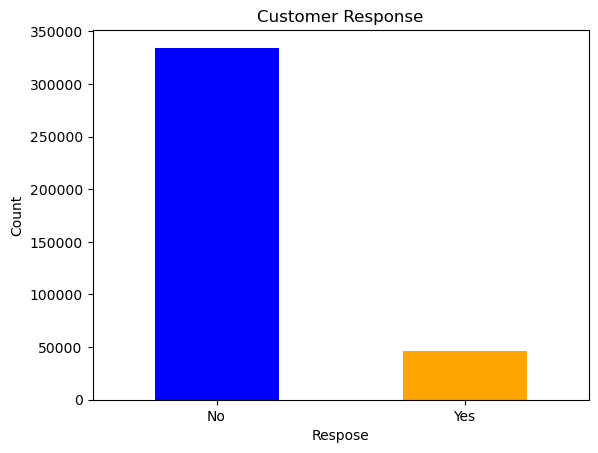

In [11]:
import matplotlib.pyplot as plt

train_df['Response'].value_counts().plot(kind='bar', color=['blue', 'orange'])
plt.title('Customer Response')
plt.xlabel('Respose')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['No', 'Yes'], rotation=0)

plt.show()

In [12]:
total = len(train_df['Response'])
percent = [val / total for val in train_df['Response'].value_counts()]

percent

[0.877436638861848, 0.12256336113815208]

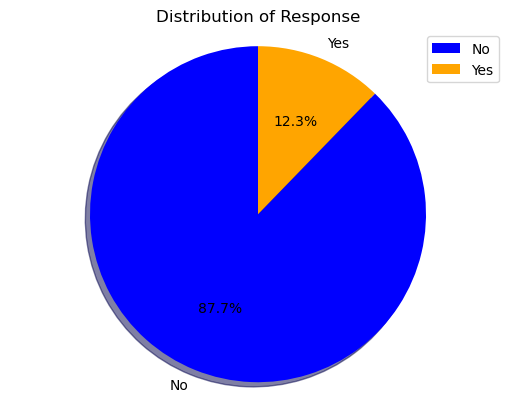

In [13]:
labels = ['No', 'Yes']

plt.pie(percent,
        labels=labels,
        autopct='%.1f%%',
        startangle=90, shadow=True,
        colors=['blue', 'orange'])
plt.title('Distribution of Response')
plt.axis('equal')

plt.legend(loc='upper right')
plt.show()

## **Sampling**

### **Example**

In [14]:
def print_result(y, y_resampled):
    print('Before')
    print(f'클래스 0 샘플 수: {sum(y == 0)}')
    print(f'클래스 1 샘플 수: {sum(y == 1)}')

    print('After')
    print(f'클래스 0 샘플 수: {sum(y_resampled == 0)}')
    print(f'클래스 1 샘플 수: {sum(y_resampled == 1)}')

In [15]:
def visualized_sampling(x, y, x_resampled, y_resampled, method_name):
    plt.figure(figsize=(10, 5))

    plt.subplot(1, 2, 1)
    plt.scatter(x[y==0][:, 0],
                x[y==0][:, 1],
                label='Class 0',
                alpha=0.5) # Class 0
    plt.scatter(x[y==1][:, 0],
                x[y==1][:, 1],
                label='Class 1',
                alpha=0.5) # Class 1

    plt.title('Original Data Distribution')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.scatter(x_resampled[y_resampled==0][:, 0],
                x_resampled[y_resampled==0][:, 1],
                label='Class 0',
                alpha=0.5) # Class 0
    plt.scatter(x_resampled[y_resampled==1][:, 0],
                x_resampled[y_resampled==1][:, 1],
                label='Class 1',
                alpha=0.5) # Class 1

    plt.title(f'Data Distribution after {method_name}')
    plt.legend()

    plt.tight_layout()
    plt.show()

In [16]:
from sklearn.datasets import make_classification
from imblearn.over_sampling import SMOTE

x, y = make_classification(
    n_classes=2,
    class_sep=2,
    weights=[0.1, 0.9],
    flip_y=0,
    n_clusters_per_class=1,
    n_samples=1000,
    random_state=10
)

In [17]:
x.shape, y.shape

((1000, 20), (1000,))

In [18]:
smote = SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(x, y)

In [19]:
print_result(y, y_resampled)

Before
클래스 0 샘플 수: 100
클래스 1 샘플 수: 900
After
클래스 0 샘플 수: 900
클래스 1 샘플 수: 900


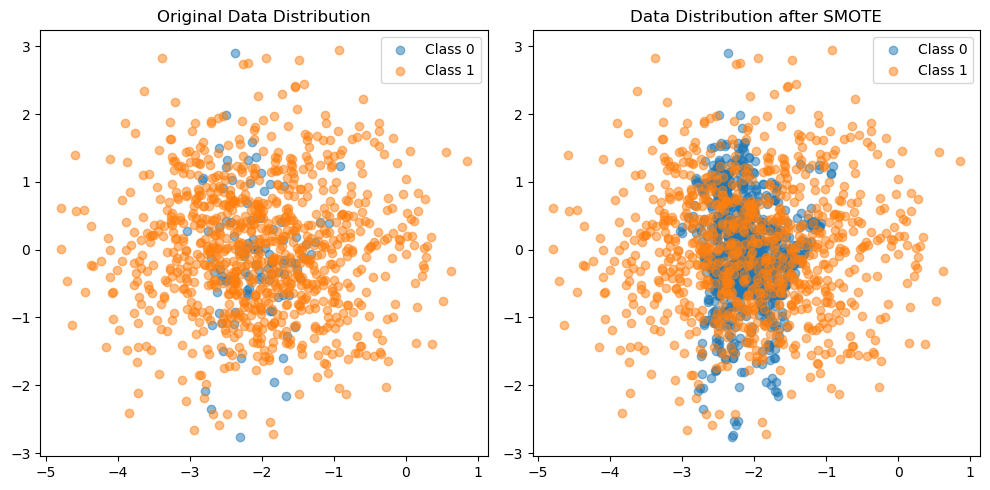

In [20]:
visualized_sampling(x, y, x_resampled, y_resampled, 'SMOTE')

In [21]:
from imblearn.under_sampling import RandomUnderSampler

x, y = make_classification(
    n_classes=2,
    class_sep=2,
    weights=[0.1, 0.9],
    flip_y=0,
    n_clusters_per_class=1,
    n_samples=1000,
    random_state=10
)

In [22]:
rns = RandomUnderSampler(random_state=42)
x_resampled, y_resampled = rns.fit_resample(x, y)

In [23]:
print_result(y, y_resampled)

Before
클래스 0 샘플 수: 100
클래스 1 샘플 수: 900
After
클래스 0 샘플 수: 100
클래스 1 샘플 수: 100


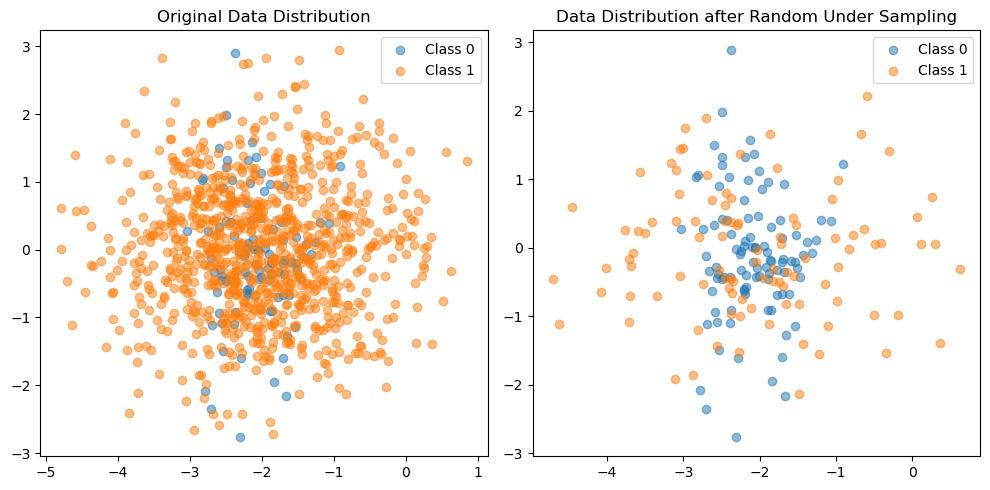

In [24]:
visualized_sampling(x, y, x_resampled, y_resampled, 'Random Under Sampling')

### **Sampling Our Data**

In [25]:
# 언더샘플링을 적용해도 적은 데이터 수가 40000개 정도로 충분하기 때문에
# 언더샘플링 적용
x = train_df.drop('Response', axis=1)
y = train_df['Response']

In [26]:
rns = RandomUnderSampler(random_state=42)
x_resampled, y_resampled = rns.fit_resample(x, y)

In [27]:
x_resampled.shape, y_resampled.shape

((93420, 11), (93420,))

In [28]:
resampled_train_df = pd.concat([x_resampled, y_resampled], axis=1).reset_index(drop=True)
resampled_train_df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,79510,0,22,1,19.0,1,0,0,54559.0,152.0,87,0
1,186555,1,57,1,18.0,0,1,1,33439.0,124.0,63,0
2,158037,0,64,1,28.0,0,1,1,39327.0,122.0,45,0
3,343706,1,52,1,41.0,1,1,0,26536.0,124.0,161,0
4,137903,0,21,1,7.0,0,0,0,28416.0,152.0,92,0


In [29]:
resampled_train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93420 entries, 0 to 93419
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    93420 non-null  int64  
 1   Gender                93420 non-null  int64  
 2   Age                   93420 non-null  int64  
 3   Driving_License       93420 non-null  int64  
 4   Region_Code           93420 non-null  float64
 5   Previously_Insured    93420 non-null  int64  
 6   Vehicle_Age           93420 non-null  int64  
 7   Vehicle_Damage        93420 non-null  int64  
 8   Annual_Premium        93420 non-null  float64
 9   Policy_Sales_Channel  93420 non-null  float64
 10  Vintage               93420 non-null  int64  
 11  Response              93420 non-null  int64  
dtypes: float64(3), int64(9)
memory usage: 8.6 MB


In [30]:
print('Original Class Distribution')
print(train_df['Response'].value_counts())

print('\nResampled Class Distribution')
print(resampled_train_df['Response'].value_counts())

Original Class Distribution
Response
0    334399
1     46710
Name: count, dtype: int64

Resampled Class Distribution
Response
0    46710
1    46710
Name: count, dtype: int64


## **Check Distribution of Data**

In [31]:
resampled_train_df.head(10)

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,79510,0,22,1,19.0,1,0,0,54559.0,152.0,87,0
1,186555,1,57,1,18.0,0,1,1,33439.0,124.0,63,0
2,158037,0,64,1,28.0,0,1,1,39327.0,122.0,45,0
3,343706,1,52,1,41.0,1,1,0,26536.0,124.0,161,0
4,137903,0,21,1,7.0,0,0,0,28416.0,152.0,92,0
5,269651,1,59,1,28.0,0,2,1,31842.0,60.0,296,0
6,357050,0,48,1,40.0,0,1,1,33565.0,26.0,202,0
7,359012,1,43,1,28.0,0,1,0,38786.0,15.0,261,0
8,112144,1,24,1,47.0,1,0,0,29291.0,152.0,226,0
9,230709,1,47,1,0.0,0,2,1,2630.0,26.0,296,0


### **Numerical Variables**

In [32]:
numerical_columns = ['Age', 'Region_Code', 'Annual_Premium', 'Vintage']

In [33]:
resampled_train_df[numerical_columns].describe()

,Age,Region_Code,Annual_Premium,Vintage
count,93420.000000,93420.000000,93420.000000,93420.000000
mean,40.819139,26.557878,30989.222265,154.683933
std,14.359740,12.641932,17695.332595,83.575008
min,20.000000,0.000000,2630.000000,10.000000
25%,27.000000,16.000000,24506.000000,82.000000
50%,41.000000,28.000000,32237.500000,155.000000
75%,50.000000,34.000000,40312.000000,227.000000
max,85.000000,52.000000,540165.000000,299.000000


In [34]:
import seaborn as sns

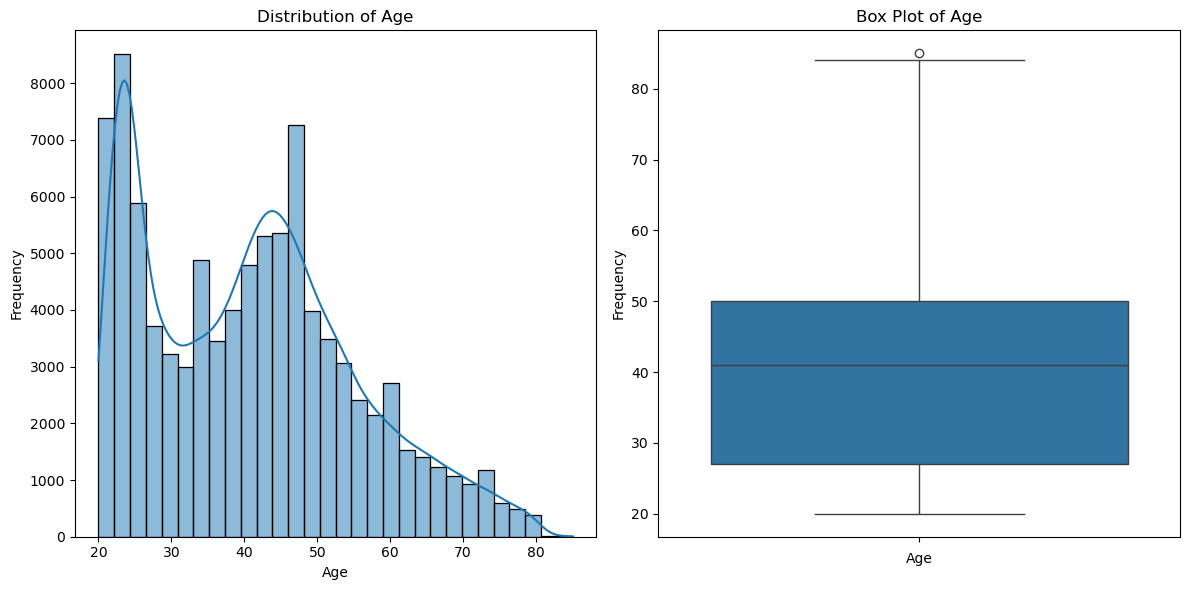

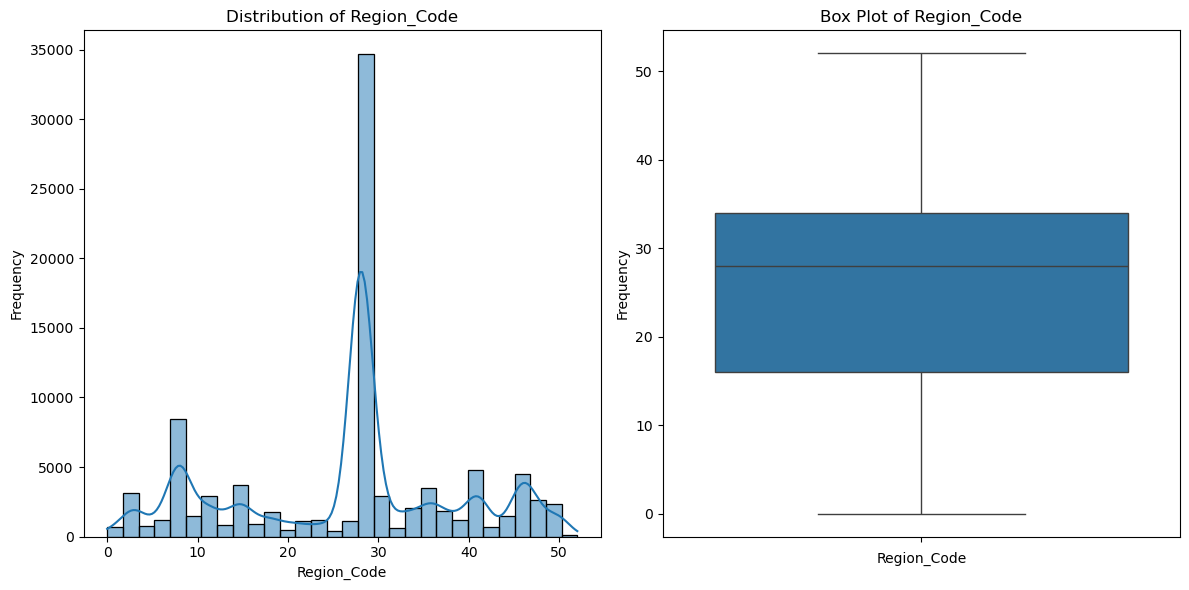

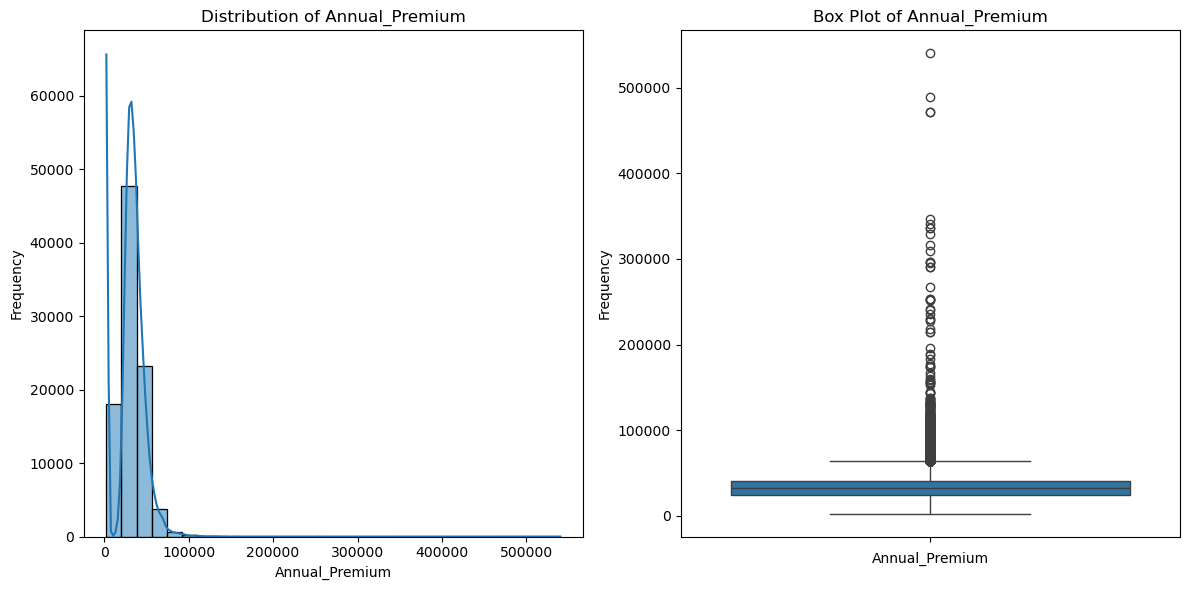

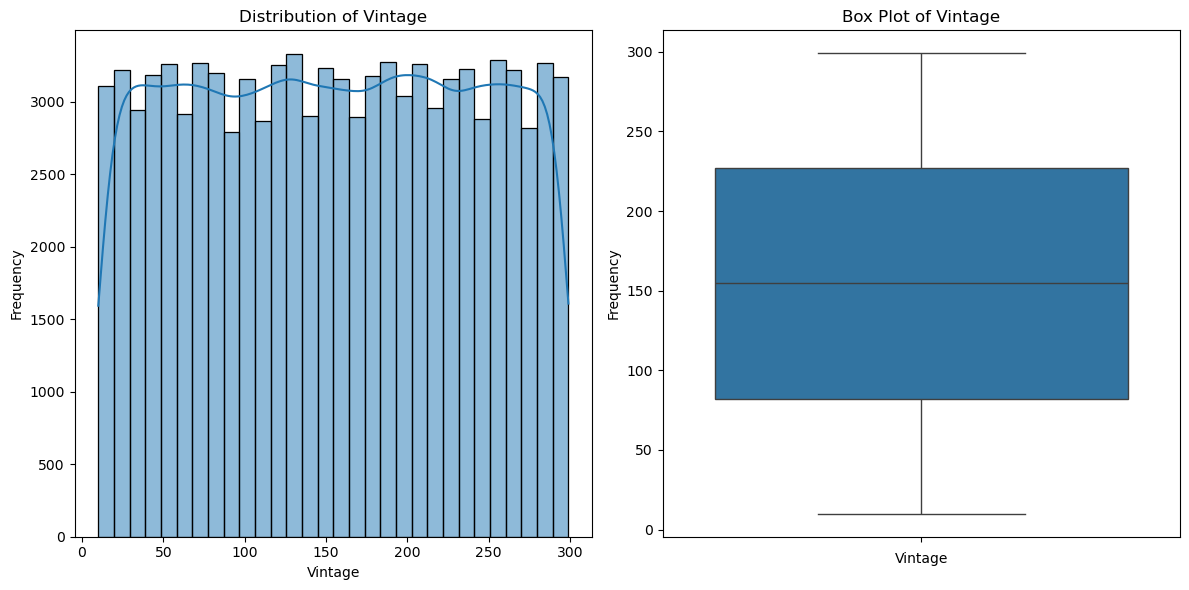

In [35]:
for col in numerical_columns:
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    sns.histplot(data=resampled_train_df,
                 x=col,
                 bins=30,
                 kde=True,
                 alpha=0.5)

    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    plt.subplot(1, 2, 2)
    sns.boxplot(data=resampled_train_df,
                y=col)

    plt.title(f'Box Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

In [36]:
# 2.46%는 적은 수이므로 제거
q1 = resampled_train_df['Annual_Premium'].quantile(0.25)
q3 = resampled_train_df['Annual_Premium'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = resampled_train_df[(resampled_train_df['Annual_Premium'] < lower_bound) | (resampled_train_df['Annual_Premium'] > upper_bound)]

print("Annual_Premium 이상치 개수:", len(outliers), f"({len(outliers) / len(resampled_train_df) * 100:.2f}%)")

Annual_Premium 이상치 개수: 2294 (2.46%)


In [37]:
resampled_train_df = resampled_train_df[
    (resampled_train_df['Annual_Premium'] >= lower_bound) & (resampled_train_df['Annual_Premium'] <= upper_bound)
].reset_index(drop=True)

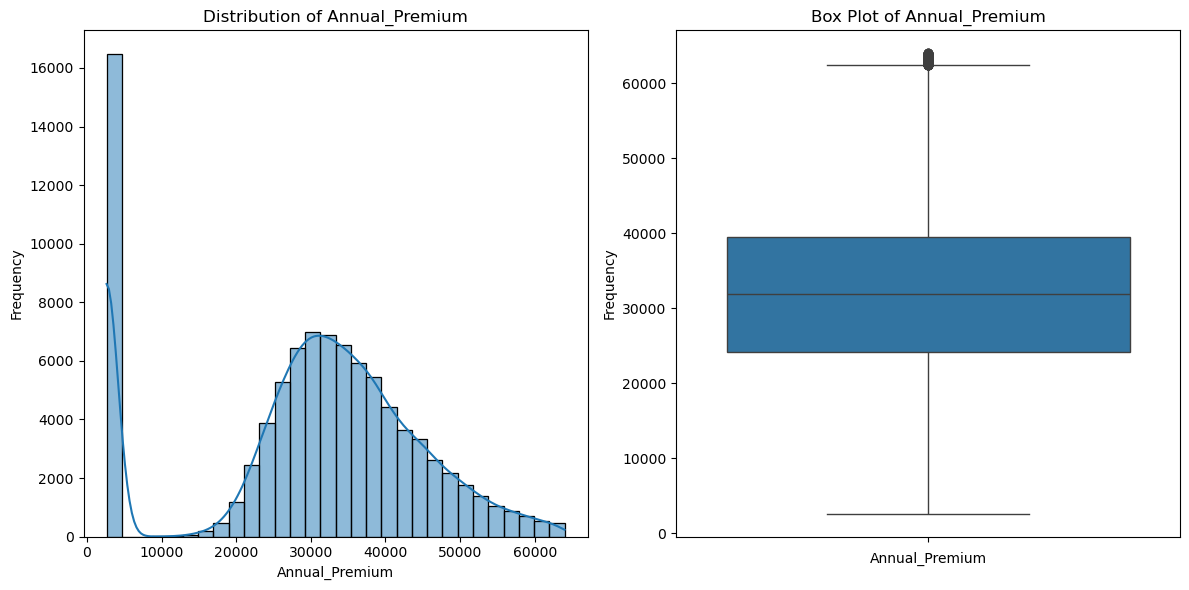

In [38]:
# 10000 이하의 값들은 정규분포를 띄는 것을 볼 수 있음
col = 'Annual_Premium'
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.histplot(data=resampled_train_df,
             x=col,
             bins=30,
             kde=True,
             alpha=0.5)

plt.title(f'Distribution of {col}')
plt.xlabel(col)
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
sns.boxplot(data=resampled_train_df,
            y=col)

plt.title(f'Box Plot of {col}')
plt.xlabel(col)
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [39]:
ap_under_10000 = resampled_train_df[resampled_train_df['Annual_Premium'] < 10000]
total = len(ap_under_10000)

ap_under_10000['Response'].value_counts() / total * 100

Response
1    51.667375
0    48.332625
Name: count, dtype: float64

### **Categorical Variables**

In [40]:
resampled_train_df.head(10)

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,79510,0,22,1,19.0,1,0,0,54559.0,152.0,87,0
1,186555,1,57,1,18.0,0,1,1,33439.0,124.0,63,0
2,158037,0,64,1,28.0,0,1,1,39327.0,122.0,45,0
3,343706,1,52,1,41.0,1,1,0,26536.0,124.0,161,0
4,137903,0,21,1,7.0,0,0,0,28416.0,152.0,92,0
5,269651,1,59,1,28.0,0,2,1,31842.0,60.0,296,0
6,357050,0,48,1,40.0,0,1,1,33565.0,26.0,202,0
7,359012,1,43,1,28.0,0,1,0,38786.0,15.0,261,0
8,112144,1,24,1,47.0,1,0,0,29291.0,152.0,226,0
9,230709,1,47,1,0.0,0,2,1,2630.0,26.0,296,0


In [41]:
categorical_columns = ['Gender', 'Driving_License', 'Previously_Insured', 'Vehicle_Age', 'Vehicle_Damage']

In [42]:
resampled_train_df[categorical_columns].head(10)

,Gender,Driving_License,Previously_Insured,Vehicle_Age,Vehicle_Damage
0,0,1,1,0,0
1,1,1,0,1,1
2,0,1,0,1,1
3,1,1,1,1,0
4,0,1,0,0,0
5,1,1,0,2,1
6,0,1,0,1,1
7,1,1,0,1,0
8,1,1,1,0,0
9,1,1,0,2,1


In [43]:
gender_mapping = {'Female': 0, 'Male': 1}
driving_license_mapping = {'No': 0, 'Yes': 1}
previously_insured_mapping = {'No': 0, 'Yes': 1}
vehicle_age_mapping = {'< 1 Year': 0, '1-2 Year': 1, '> 2 Years': 2}
vehicle_damage_mapping = {'No': 0, 'Yes': 1}

mappings = [gender_mapping, driving_license_mapping, previously_insured_mapping, vehicle_age_mapping, vehicle_damage_mapping]

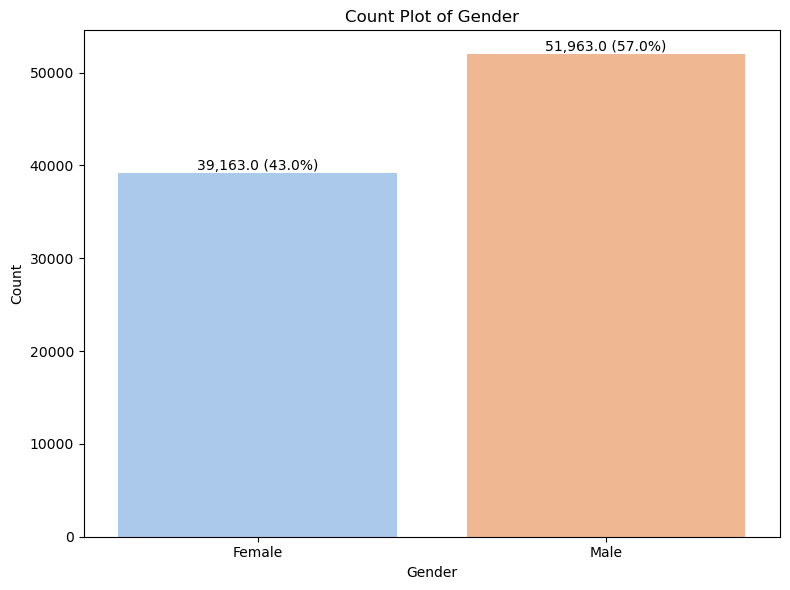

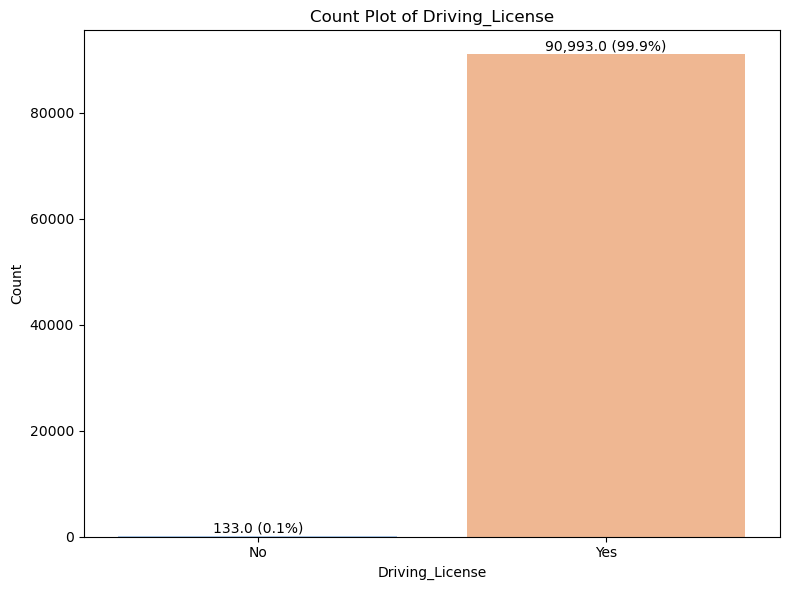

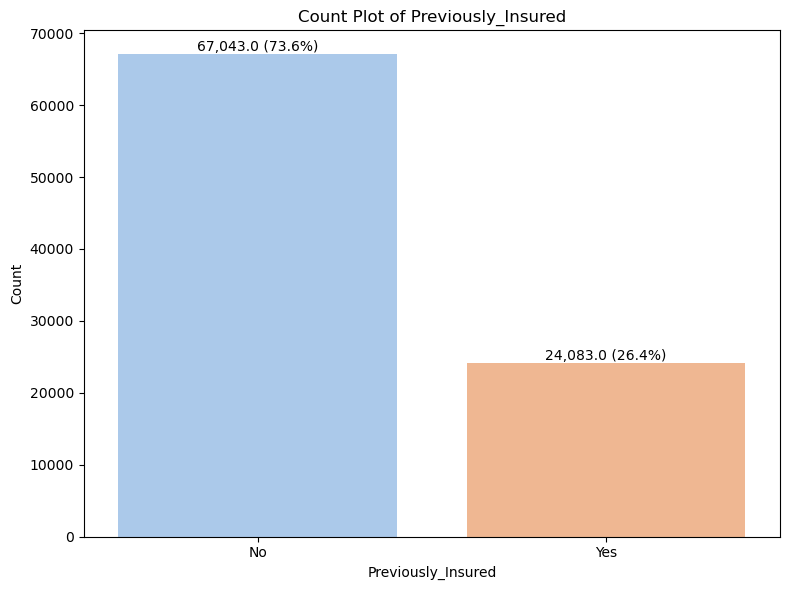

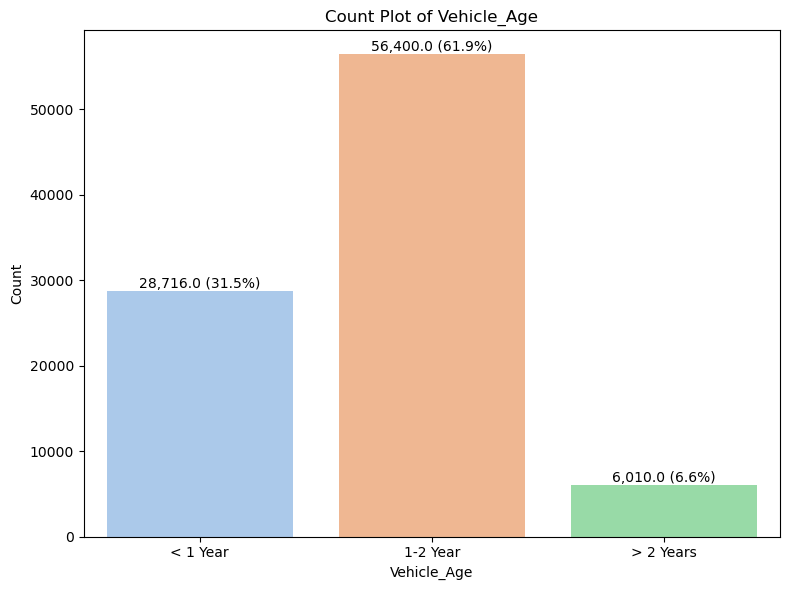

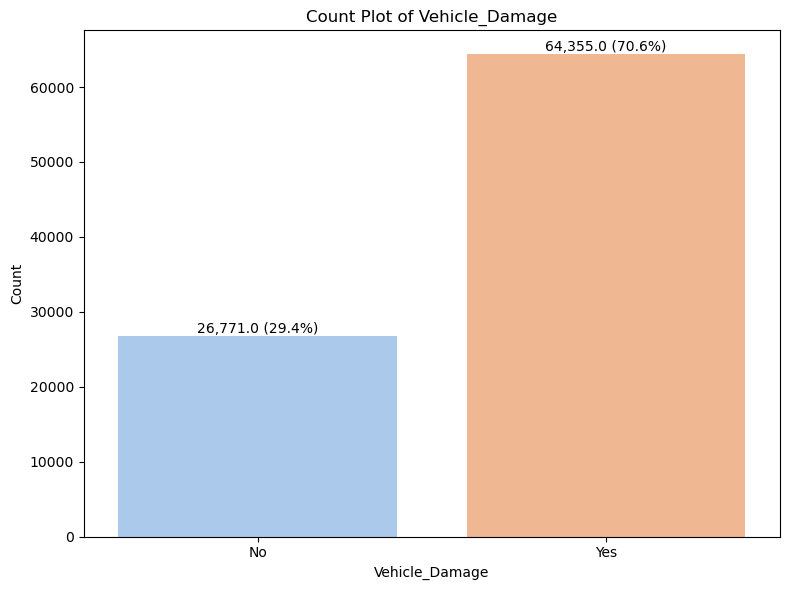

In [44]:
for idx in range(len(categorical_columns)):
    col = categorical_columns[idx]
    mapping = mappings[idx]

    plt.figure(figsize=(8, 6))

    sns.countplot(data=resampled_train_df,
                  x=col,
                  hue=col,
                  palette='pastel',
                  legend=False)
    plt.title(f'Count Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(ticks=range(len(mapping)), labels=mapping.keys())

    total = len(resampled_train_df)
    for p in plt.gca().patches:
        height = p.get_height()
        plt.text(
            p.get_x() + p.get_width() / 2,
            height,
            f'{height:,} ({height/ total:.1%})',
            ha='center',
            va='bottom')
    
    plt.tight_layout()
    plt.show()    

## **Correlation With Response**

In [45]:
corr_matrix = resampled_train_df.corr()
corr_matrix

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
id,1.000000,0.005834,0.003259,-0.002297,0.000190,0.003519,-0.002481,-0.002108,0.001714,0.001803,-0.002333,-0.004053
Gender,0.005834,1.000000,0.133473,-0.015190,-0.003507,-0.090384,0.142697,0.096443,0.008031,-0.092380,-0.001088,0.080723
Age,0.003259,0.133473,1.000000,-0.062057,0.031360,-0.261088,0.709318,0.274956,0.079302,-0.518308,-0.007505,0.181575
Driving_License,-0.002297,-0.015190,-0.062057,1.000000,0.003247,-0.001206,-0.021956,-0.000677,-0.005151,0.025832,-0.000041,0.014538
Region_Code,0.000190,-0.003507,0.031360,0.003247,1.000000,-0.020591,0.032480,0.023299,0.004542,-0.034746,-0.005927,0.014525
Previously_Insured,0.003519,-0.090384,-0.261088,-0.001206,-0.020591,1.000000,-0.400767,-0.853315,-0.005179,0.225881,0.006652,-0.589715
Vehicle_Age,-0.002481,0.142697,0.709318,-0.021956,0.032480,-0.400767,1.000000,0.416050,0.057160,-0.483431,-0.003818,0.335929
Vehicle_Damage,-0.002108,0.096443,0.274956,-0.000677,0.023299,-0.853315,0.416050,1.000000,0.021661,-0.236499,-0.004752,0.596266
Annual_Premium,0.001714,0.008031,0.079302,-0.005151,0.004542,-0.005179,0.057160,0.021661,1.000000,-0.158152,0.001665,0.028373
Policy_Sales_Channel,0.001803,-0.092380,-0.518308,0.025832,-0.034746,0.225881,-0.483431,-0.236499,-0.158152,1.000000,0.004234,-0.204969


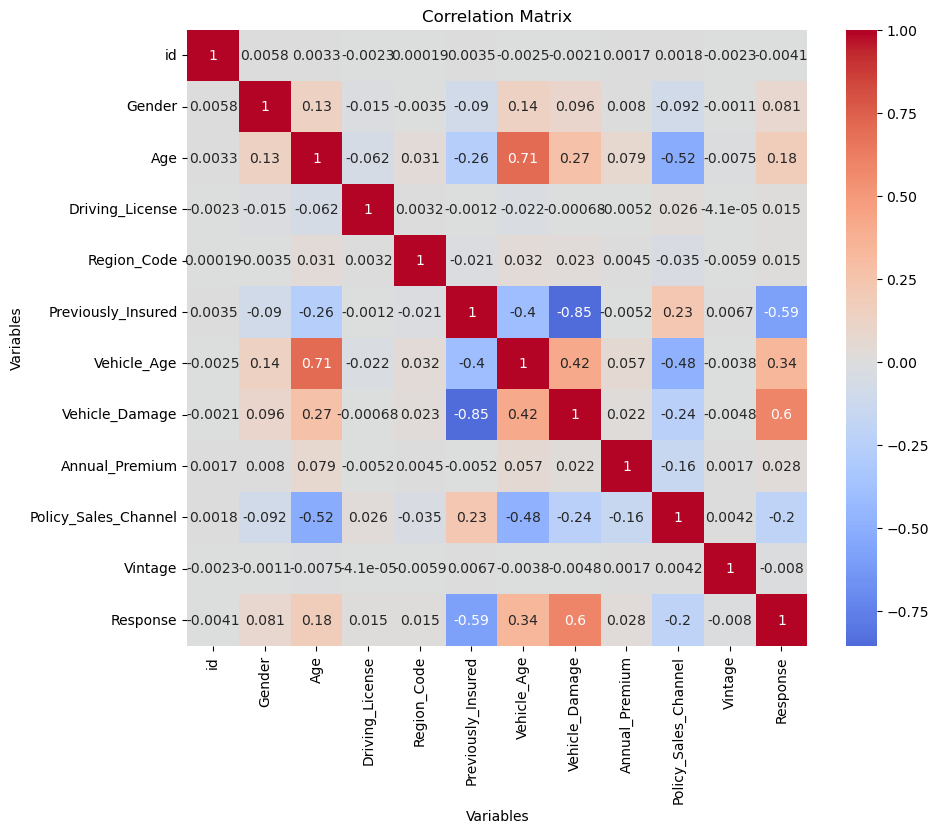

In [46]:
plt.figure(figsize=(10, 8))

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            center=0)

plt.title('Correlation Matrix')
plt.xlabel('Variables')
plt.ylabel('Variables')

plt.show()

In [47]:
print(corr_matrix['Response'].sort_values(ascending=False)[1:], '\n')

print(corr_matrix['Response'].abs().sort_values(ascending=False)[1:])

Vehicle_Damage          0.596266
Vehicle_Age             0.335929
Age                     0.181575
Gender                  0.080723
Annual_Premium          0.028373
Driving_License         0.014538
Region_Code             0.014525
id                     -0.004053
Vintage                -0.007969
Policy_Sales_Channel   -0.204969
Previously_Insured     -0.589715
Name: Response, dtype: float64 

Vehicle_Damage          0.596266
Previously_Insured      0.589715
Vehicle_Age             0.335929
Policy_Sales_Channel    0.204969
Age                     0.181575
Gender                  0.080723
Annual_Premium          0.028373
Driving_License         0.014538
Region_Code             0.014525
Vintage                 0.007969
id                      0.004053
Name: Response, dtype: float64


In [48]:
def create_count_df(data, column1, column2):
    count_df = data.groupby([column1, column2])['id'].count().to_frame().rename(columns={'id': 'count'}).reset_index()
    return count_df

### **With Vehicle_Damage**

In [49]:
response_counts_by_damage = create_count_df(resampled_train_df, 'Vehicle_Damage', 'Response')
response_counts_by_damage

,Vehicle_Damage,Response,count
0,0,0,25803
1,0,1,968
2,1,0,19906
3,1,1,44449


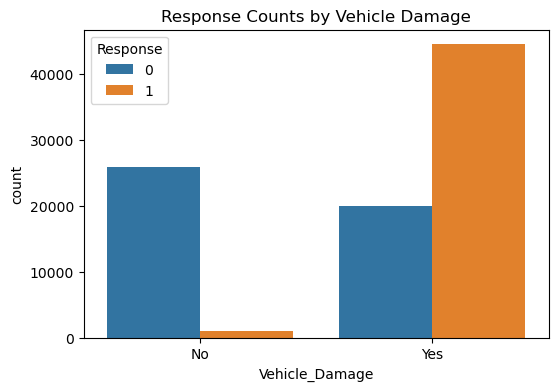

In [50]:
plt.figure(figsize=(6, 4))

sns.barplot(
    x='Vehicle_Damage',
    y='count',
    hue='Response',
    data=response_counts_by_damage
)

x_labels = vehicle_damage_mapping.keys()

plt.xticks(ticks=[0, 1], labels=x_labels)
plt.title('Response Counts by Vehicle Damage')
plt.show()

### **With Vehicle_Age**

In [51]:
response_counts_by_age = create_count_df(resampled_train_df, 'Vehicle_Age', 'Response')
response_counts_by_age

,Vehicle_Age,Response,count
0,0,0,21630
1,0,1,7086
2,1,0,22483
3,1,1,33917
4,2,0,1596
5,2,1,4414


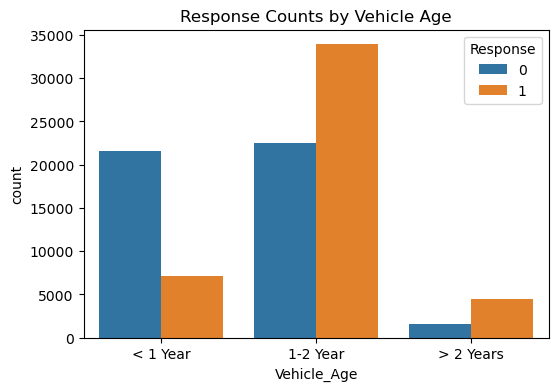

In [52]:
plt.figure(figsize=(6, 4))

sns.barplot(
    x='Vehicle_Age',
    y='count',
    hue='Response',
    data=response_counts_by_age
)

x_labels = vehicle_age_mapping.keys()

plt.xticks(ticks=[0, 1, 2], labels=x_labels)
plt.title('Response Counts by Vehicle Age')
plt.show()

### **With Previously_Insured**

In [53]:
response_counts_by_insured = create_count_df(resampled_train_df, 'Previously_Insured', 'Response')
response_counts_by_insured

,Previously_Insured,Response,count
0,0,0,21781
1,0,1,45262
2,1,0,23928
3,1,1,155


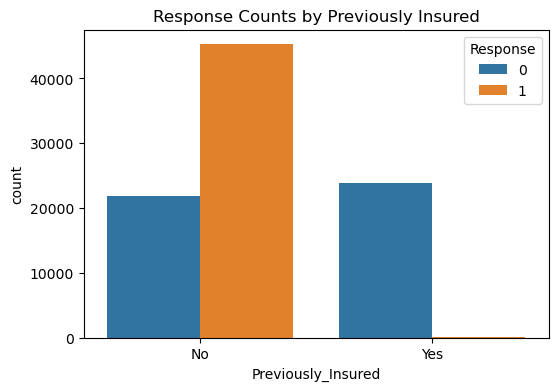

In [54]:
plt.figure(figsize=(6, 4))

sns.barplot(
    x='Previously_Insured',
    y='count',
    hue='Response',
    data=response_counts_by_insured
)

x_labels = previously_insured_mapping.keys()

plt.xticks(ticks=[0, 1], labels=x_labels)
plt.title('Response Counts by Previously Insured')
plt.show()

### **With Annual_Premium**

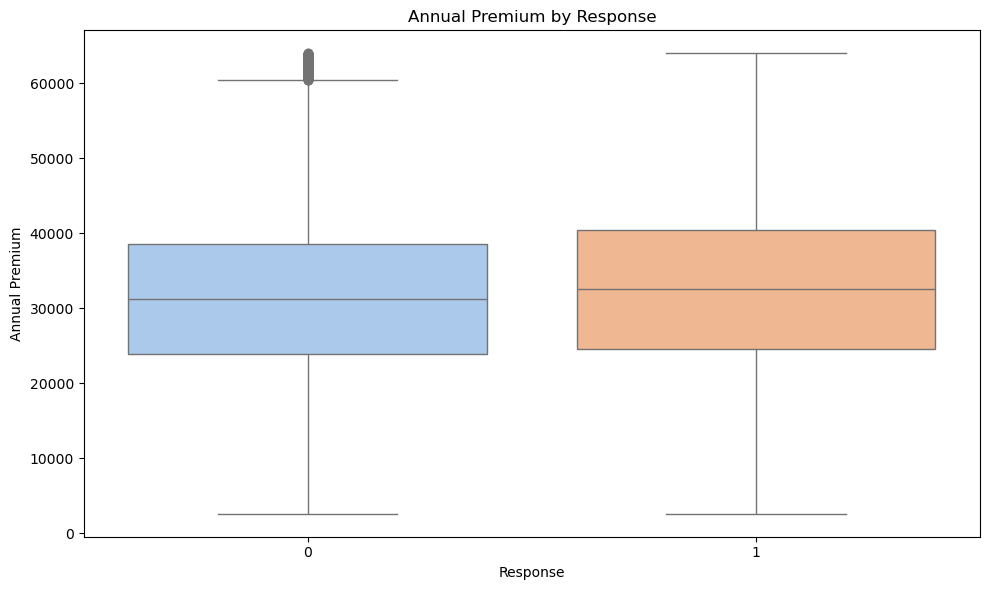

In [55]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=resampled_train_df,
            x='Response',
            y='Annual_Premium',
            hue='Response',
            palette='pastel',
            legend=False)

plt.title('Annual Premium by Response')
plt.xlabel('Response')
plt.ylabel('Annual Premium')

plt.tight_layout()
plt.show()

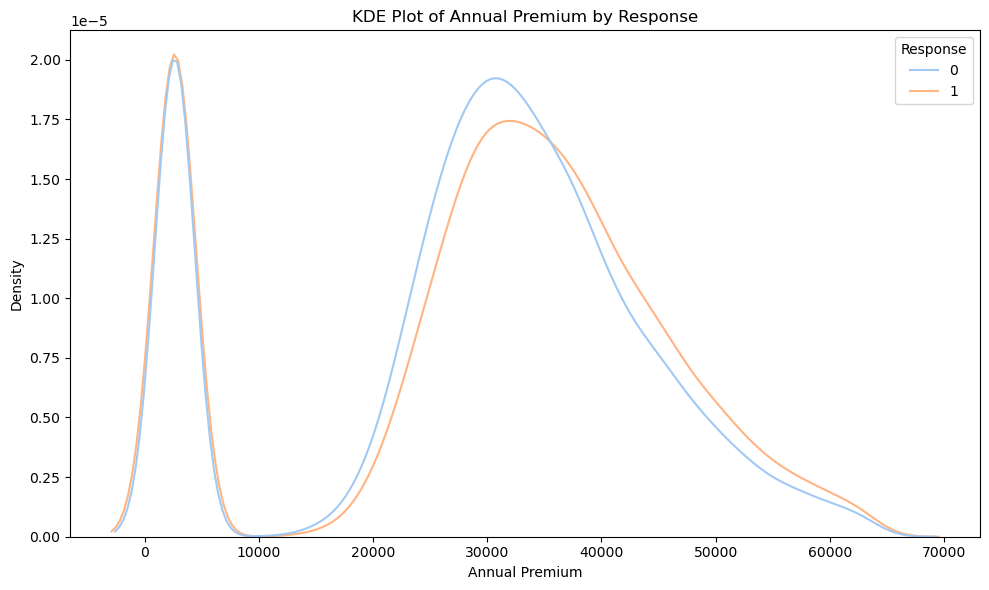

In [56]:
plt.figure(figsize=(10, 6))

sns.kdeplot(data=resampled_train_df,
            x='Annual_Premium',
            hue='Response',
            palette='pastel')

plt.title('KDE Plot of Annual Premium by Response')
plt.xlabel('Annual Premium')
plt.ylabel('Density')

plt.tight_layout()
plt.show()

In [57]:
data = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
df = pd.DataFrame(data, columns=['value'])

df['Quantile_Group'] = pd.qcut(df['value'], q=3)

print(df)

   value Quantile_Group
0     10  (9.999, 40.0]
1     20  (9.999, 40.0]
2     30  (9.999, 40.0]
3     40   (40.0, 70.0]
4     50   (40.0, 70.0]
5     60   (40.0, 70.0]
6     70  (70.0, 100.0]
7     80  (70.0, 100.0]
8     90  (70.0, 100.0]
9    100  (70.0, 100.0]


In [58]:
resampled_train_df['Premium_Group'] = pd.qcut(resampled_train_df['Annual_Premium'], q=10, duplicates='drop')

premium_response_avg = resampled_train_df.groupby('Premium_Group', observed=False)['Response'].mean().reset_index()
premium_response_avg

,Premium_Group,Response
0,"(2629.999, 20846.0]",0.503813
1,"(20846.0, 26207.0]",0.428336
2,"(26207.0, 29235.0]",0.459394
3,"(29235.0, 31899.0]",0.472408
4,"(31899.0, 34693.0]",0.485401
5,"(34693.0, 37767.0]",0.502688
6,"(37767.0, 41652.0]",0.527113
7,"(41652.0, 47475.0]",0.545764
8,"(47475.0, 64004.0]",0.555251


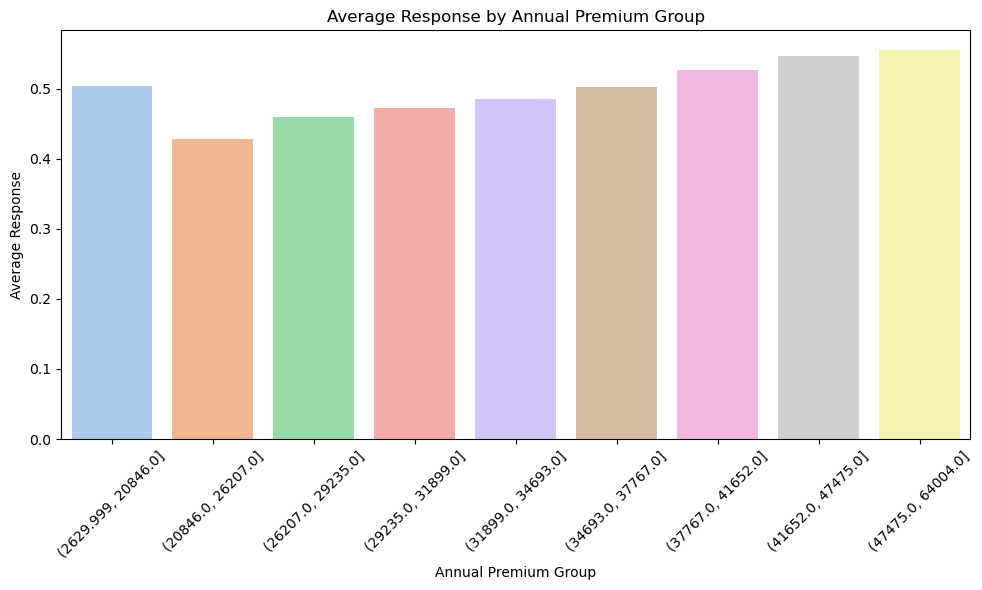

In [59]:
plt.figure(figsize=(10, 6))

sns.barplot(data=premium_response_avg,
            x='Premium_Group',
            y='Response',
            hue='Premium_Group',
            palette='pastel',
            legend=False)

plt.title('Average Response by Annual Premium Group')
plt.xlabel('Annual Premium Group')
plt.ylabel('Average Response')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [60]:
resampled_train_df.groupby('Premium_Group', observed=False)['id'].count()

Premium_Group
(2629.999, 20846.0]    18227
(20846.0, 26207.0]      9112
(26207.0, 29235.0]      9112
(29235.0, 31899.0]      9115
(31899.0, 34693.0]      9110
(34693.0, 37767.0]      9115
(37767.0, 41652.0]      9110
(41652.0, 47475.0]      9112
(47475.0, 64004.0]      9113
Name: id, dtype: int64

## **Make Customer Value Score - Bins**

In [61]:
print(corr_matrix['Response'].sort_values(ascending=False)[1:][:5], '\n')
print(corr_matrix['Response'].abs().sort_values(ascending=False)[1:][:5])

Vehicle_Damage    0.596266
Vehicle_Age       0.335929
Age               0.181575
Gender            0.080723
Annual_Premium    0.028373
Name: Response, dtype: float64 

Vehicle_Damage          0.596266
Previously_Insured      0.589715
Vehicle_Age             0.335929
Policy_Sales_Channel    0.204969
Age                     0.181575
Name: Response, dtype: float64


In [62]:
resampled_train_df['Policy_Sales_Channel'].unique()

array([152., 124., 122.,  60.,  26.,  15.,   4., 160., 151.,  25., 139.,
       154., 150.,  14.,  55., 157.,   8.,  24., 135., 156.,  29.,  11.,
        12.,   7., 125., 109., 128., 155., 107., 159., 163.,  13.,   9.,
       158.,  61., 131., 136.,  16.,  69.,   1.,   3.,  52.,  18., 147.,
       106.,  37., 120., 114., 148.,  21., 118., 153.,  30., 132.,  22.,
        31.,  40., 111.,  19.,  64., 116.,  92., 127., 140.,  23.,  10.,
        44.,  35.,  59., 130., 103., 145.,  54.,  56.,  36., 134.,  73.,
       146., 113.,  42.,  95.,  38., 138.,  88.,  63., 119.,  47.,  49.,
        32.,  20., 121.,  91.,  48.,  80.,  51., 108.,  94.,  97.,  89.,
        65.,  66.,  45.,  98., 133., 126.,  87.,  71., 143., 129.,  86.,
        50.,  96.,  46., 101.,  78., 115.,  27.,  90.,  58.,  93.,  81.,
        39., 123.,  28.,  53.,  62., 110.,  68.,  43.,  17., 100.,   2.,
        57.])

In [63]:
response_rate_by_channel = resampled_train_df.groupby('Policy_Sales_Channel')['Response'].mean().reset_index()
response_rate_by_channel.head(10)

,Policy_Sales_Channel,Response
0,1.0,0.196629
1,2.0,1.000000
2,3.0,0.743590
3,4.0,0.606250
4,7.0,0.502793
5,8.0,0.427586
6,9.0,0.369565
7,10.0,0.666667
8,11.0,0.386282
9,12.0,0.607656


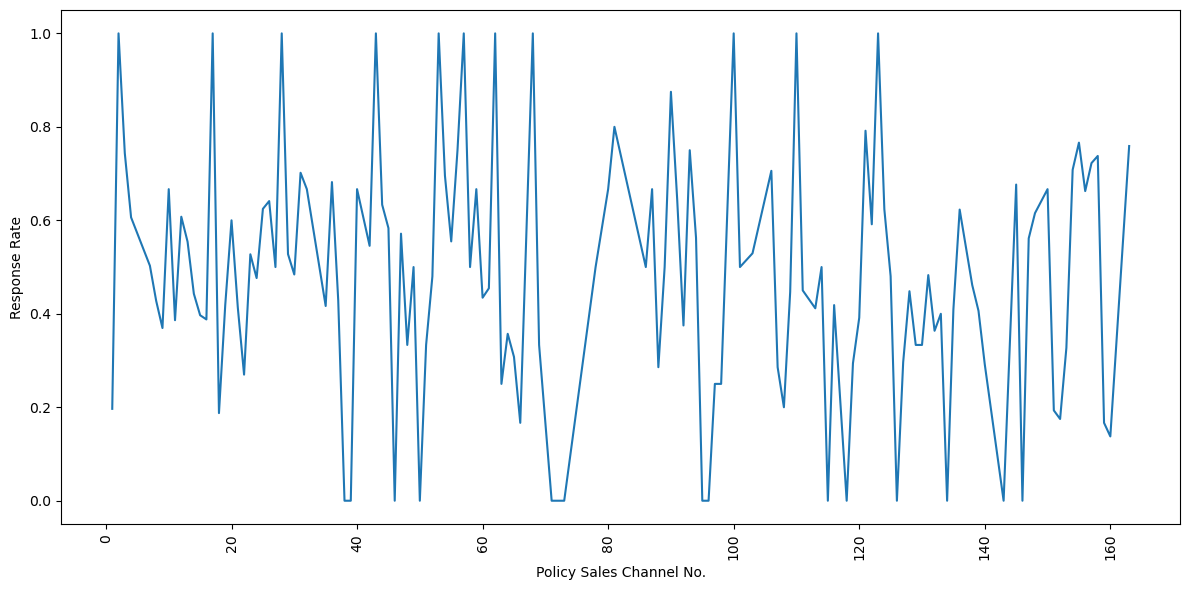

In [64]:
# 상관관계 확인 안됨
plt.figure(figsize=(12, 6))
sns.lineplot(data=response_rate_by_channel,
             x='Policy_Sales_Channel',
             y='Response')

plt.xlabel('Policy Sales Channel No.')
plt.ylabel('Response Rate')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [65]:
response_rate_by_age = resampled_train_df.groupby('Age')['Response'].mean().reset_index()
response_rate_by_age.head(10)

,Age,Response
0,20,0.168307
1,21,0.204398
2,22,0.214061
3,23,0.217520
4,24,0.209146
5,25,0.206245
6,26,0.208589
7,27,0.241689
8,28,0.345672
9,29,0.451183


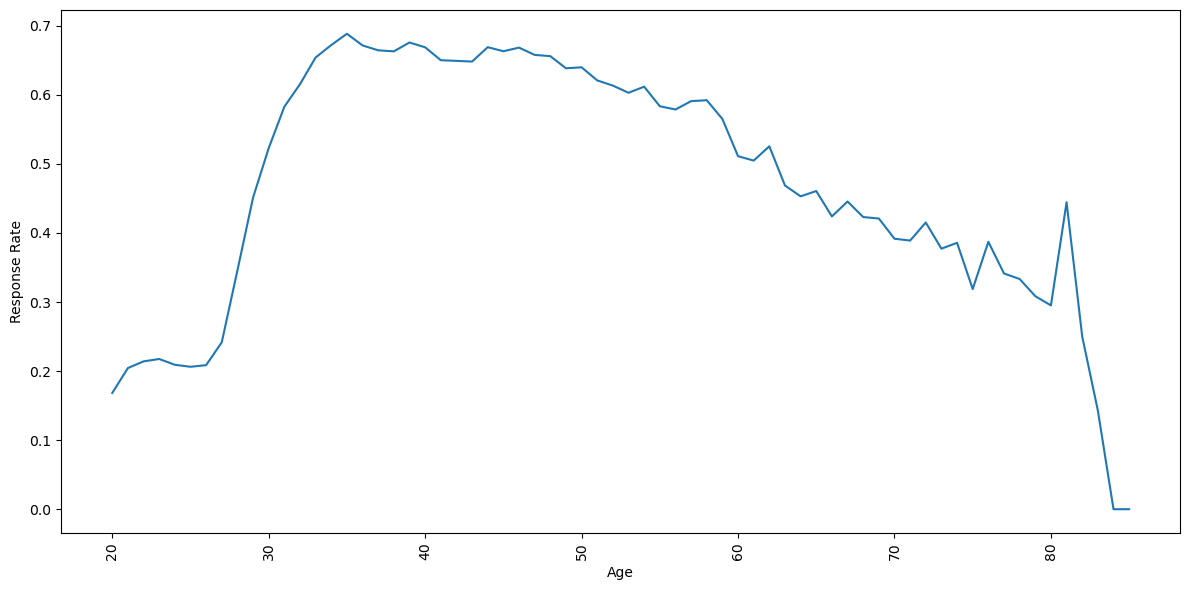

In [66]:
# Policy_Sales_Channel보다 상관계수가 낮지만,
# Age는 우하향하는 추세를 보임
plt.figure(figsize=(12, 6))
sns.lineplot(data=response_rate_by_age,
             x='Age',
             y='Response')

plt.xlabel('Age')
plt.ylabel('Response Rate')
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [67]:
display(response_rate_by_channel.head(10))
display(response_rate_by_age.head(10))

,Policy_Sales_Channel,Response
0,1.0,0.196629
1,2.0,1.000000
2,3.0,0.743590
3,4.0,0.606250
4,7.0,0.502793
5,8.0,0.427586
6,9.0,0.369565
7,10.0,0.666667
8,11.0,0.386282
9,12.0,0.607656


,Age,Response
0,20,0.168307
1,21,0.204398
2,22,0.214061
3,23,0.217520
4,24,0.209146
5,25,0.206245
6,26,0.208589
7,27,0.241689
8,28,0.345672
9,29,0.451183


In [68]:
response_bins = [-0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
response_labels = [1, 2, 3, 4, 5]

In [69]:
response_rate_by_channel['Response_Bin'] = pd.cut(response_rate_by_channel['Response'], bins=response_bins, labels=response_labels)
response_rate_by_channel.head(10)

,Policy_Sales_Channel,Response,Response_Bin
0,1.0,0.196629,1
1,2.0,1.000000,5
2,3.0,0.743590,4
3,4.0,0.606250,4
4,7.0,0.502793,3
5,8.0,0.427586,3
6,9.0,0.369565,2
7,10.0,0.666667,4
8,11.0,0.386282,2
9,12.0,0.607656,4


In [70]:
response_rate_by_age['Response_Bin'] = pd.cut(response_rate_by_age['Response'], bins=response_bins, labels=response_labels)
response_rate_by_age.head(10)

,Age,Response,Response_Bin
0,20,0.168307,1
1,21,0.204398,2
2,22,0.214061,2
3,23,0.217520,2
4,24,0.209146,2
5,25,0.206245,2
6,26,0.208589,2
7,27,0.241689,2
8,28,0.345672,2
9,29,0.451183,3


In [71]:
resampled_train_df['Response_Bin_Channel'] = pd.cut(
    resampled_train_df['Policy_Sales_Channel'].map(
        response_rate_by_channel.set_index('Policy_Sales_Channel')['Response']),
    bins=response_bins, labels=response_labels
)

resampled_train_df['Response_Bin_Age'] = pd.cut(
    resampled_train_df['Age'].map(
        response_rate_by_age.set_index('Age')['Response']),
    bins=response_bins, labels=response_labels
)

In [72]:
resampled_train_df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response,Premium_Group,Response_Bin_Channel,Response_Bin_Age
0,79510,0,22,1,19.0,1,0,0,54559.0,152.0,87,0,"(47475.0, 64004.0]",1,2
1,186555,1,57,1,18.0,0,1,1,33439.0,124.0,63,0,"(31899.0, 34693.0]",4,3
2,158037,0,64,1,28.0,0,1,1,39327.0,122.0,45,0,"(37767.0, 41652.0]",3,3
3,343706,1,52,1,41.0,1,1,0,26536.0,124.0,161,0,"(26207.0, 29235.0]",4,4
4,137903,0,21,1,7.0,0,0,0,28416.0,152.0,92,0,"(26207.0, 29235.0]",1,2


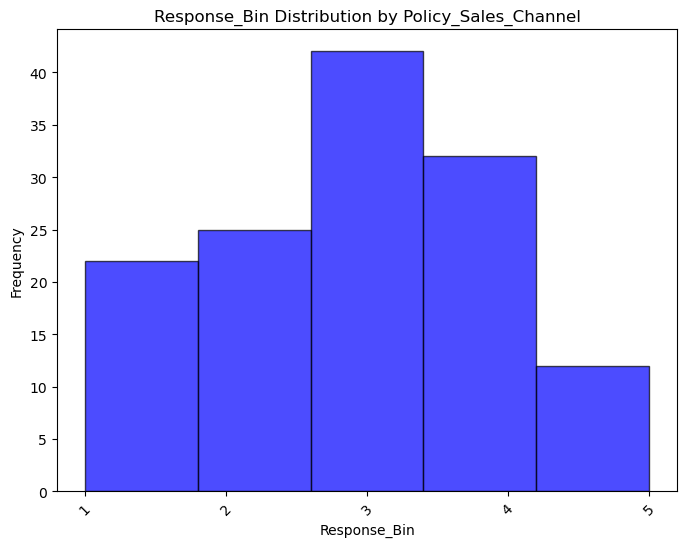

In [73]:
plt.figure(figsize=(8, 6))

plt.hist(response_rate_by_channel['Response_Bin'],
         bins=len(response_labels),
         alpha=0.7,
         color='blue',
         edgecolor='black')

plt.title('Response_Bin Distribution by Policy_Sales_Channel')
plt.xlabel('Response_Bin')
plt.ylabel('Frequency')

plt.xticks(response_labels, rotation=45)
plt.show()

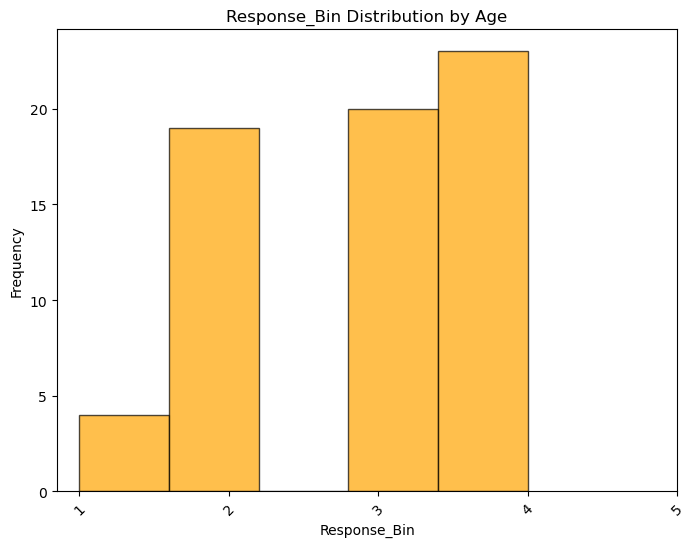

In [74]:
plt.figure(figsize=(8, 6))

plt.hist(response_rate_by_age['Response_Bin'],
         bins=len(response_labels),
         alpha=0.7,
         color='orange',
         edgecolor='black')

plt.title('Response_Bin Distribution by Age')
plt.xlabel('Response_Bin')
plt.ylabel('Frequency')

plt.xticks(response_labels, rotation=45)
plt.show()

In [75]:
print(sorted(resampled_train_df[resampled_train_df['Response_Bin_Channel'] == 5]['Policy_Sales_Channel'].unique()))

[2.0, 17.0, 28.0, 43.0, 53.0, 57.0, 62.0, 68.0, 90.0, 100.0, 110.0, 123.0]


In [76]:
print(sorted(resampled_train_df[resampled_train_df['Response_Bin_Age'] == 4]['Age'].unique()))

[32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54]


## **Make Customer Value Score - Logic**

In [78]:
columns_for_corr = corr_matrix['Response'].abs().sort_values(ascending=False)[1:][:5].index.to_list()
columns_for_corr

['Vehicle_Damage',
 'Previously_Insured',
 'Vehicle_Age',
 'Policy_Sales_Channel',
 'Age']

In [79]:
corr_weights = dict()

corr_weights_kv = [(col, corr_matrix['Response'][col]) for col in columns_for_corr]
for key, value in corr_weights_kv:
    corr_weights[key] = abs(value)
corr_weights

{'Vehicle_Damage': 0.5962662600297487,
 'Previously_Insured': 0.5897149446806905,
 'Vehicle_Age': 0.335928706474583,
 'Policy_Sales_Channel': 0.20496925714596706,
 'Age': 0.1815754926733999}

In [80]:
columns_for_score = corr_matrix['Response'].abs().sort_values(ascending=False)[1:][:3].index.to_list()
columns_for_score = columns_for_score + ['Response_Bin_Channel', 'Response_Bin_Age']
columns_for_score

['Vehicle_Damage',
 'Previously_Insured',
 'Vehicle_Age',
 'Response_Bin_Channel',
 'Response_Bin_Age']

In [81]:
corr_weights['Response_Bin_Channel'] = corr_weights.pop('Policy_Sales_Channel')
corr_weights['Response_Bin_Age'] = corr_weights.pop('Age')
corr_weights

{'Vehicle_Damage': 0.5962662600297487,
 'Previously_Insured': 0.5897149446806905,
 'Vehicle_Age': 0.335928706474583,
 'Response_Bin_Channel': 0.20496925714596706,
 'Response_Bin_Age': 0.1815754926733999}

In [83]:
score_threshold = 10
response_rate_by_vehicle_age = resampled_train_df.groupby('Vehicle_Age')['Response'].mean().reset_index()
response_rate_by_vehicle_age

,Vehicle_Age,Response
0,0,0.246761
1,1,0.601365
2,2,0.734443


In [84]:
vehicle_age_score_mapping = response_rate_by_vehicle_age['Response'] * score_threshold
vehicle_age_score_mapping = vehicle_age_score_mapping.to_dict()
vehicle_age_score_mapping

{0: 2.4676138737985793, 1: 6.013652482269504, 2: 7.344425956738768}

In [85]:
channel_score_mapping = response_rate_by_channel.groupby('Response_Bin')['Response'].mean() * score_threshold
channel_score_mapping = channel_score_mapping.to_dict()
channel_score_mapping

C:\Users\samsung\AppData\Local\Temp\ipykernel_29144\2318144006.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  channel_score_mapping = response_rate_by_channel.groupby('Response_Bin')['Response'].mean() * score_threshold


{1: 0.646943366873336,
 2: 3.2812050782317415,
 3: 4.882119641284432,
 4: 6.855912311344757,
 5: 9.895833333333334}

In [86]:
age_score_mapping = response_rate_by_age.groupby('Response_Bin')['Response'].mean() * score_threshold
age_score_mapping = age_score_mapping.to_dict()
age_score_mapping

C:\Users\samsung\AppData\Local\Temp\ipykernel_29144\1456218560.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_score_mapping = response_rate_by_age.groupby('Response_Bin')['Response'].mean() * score_threshold


{1: 0.7779105736782901,
 2: 2.9606982904324357,
 3: 4.982408354826708,
 4: 6.506174722201416,
 5: nan}

In [91]:
score_mapping = {
    'Vehicle_Damage': {0: score_threshold * -1, 1: score_threshold},
    'Previously_Insured': {0: score_threshold, 1: score_threshold * -1},
    'Vehicle_Age': vehicle_age_score_mapping,
    'Response_Bin_Channel': channel_score_mapping,
    'Response_Bin_Age': age_score_mapping
}
score_mapping

{'Vehicle_Damage': {0: -10, 1: 10},
 'Previously_Insured': {0: 10, 1: -10},
 'Vehicle_Age': {0: 2.4676138737985793,
  1: 6.013652482269504,
  2: 7.344425956738768},
 'Response_Bin_Channel': {1: 0.646943366873336,
  2: 3.2812050782317415,
  3: 4.882119641284432,
  4: 6.855912311344757,
  5: 9.895833333333334},
 'Response_Bin_Age': {1: 0.7779105736782901,
  2: 2.9606982904324357,
  3: 4.982408354826708,
  4: 6.506174722201416,
  5: nan}}

In [92]:
def calculate_final_score(row):
    score_sum = 0
    for col in columns_for_score:
        score_sum += score_mapping[col][row[col]] * corr_weights[col]
    return score_sum

In [93]:
resampled_train_df['Score'] = 0

In [94]:
resampled_train_df['Score'] = resampled_train_df.apply(calculate_final_score, axis=1)
resampled_train_df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response,Premium_Group,Response_Bin_Channel,Response_Bin_Age,Score
0,79510,0,22,1,19.0,1,0,0,54559.0,152.0,87,0,"(47475.0, 64004.0]",1,2,-10.360676
1,186555,1,57,1,18.0,0,1,1,33439.0,124.0,63,0,"(31899.0, 34693.0]",4,3,16.189905
2,158037,0,64,1,28.0,0,1,1,39327.0,122.0,45,0,"(37767.0, 41652.0]",3,3,15.785338
3,343706,1,52,1,41.0,1,1,0,26536.0,124.0,161,0,"(26207.0, 29235.0]",4,4,-7.253040
4,137903,0,21,1,7.0,0,0,0,28416.0,152.0,92,0,"(26207.0, 29235.0]",1,2,1.433623


In [95]:
min_final_score = resampled_train_df['Score'].min()
max_final_score = resampled_train_df['Score'].max()
min_final_score, max_final_score

(-10.757016713405479, 17.536719046326574)

In [96]:
resampled_train_df['Final_Score'] = (resampled_train_df['Score'] - min_final_score) / (max_final_score - min_final_score)
resampled_train_df.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response,Premium_Group,Response_Bin_Channel,Response_Bin_Age,Score,Final_Score
0,79510,0,22,1,19.0,1,0,0,54559.0,152.0,87,0,"(47475.0, 64004.0]",1,2,-10.360676,0.014008
1,186555,1,57,1,18.0,0,1,1,33439.0,124.0,63,0,"(31899.0, 34693.0]",4,3,16.189905,0.952399
2,158037,0,64,1,28.0,0,1,1,39327.0,122.0,45,0,"(37767.0, 41652.0]",3,3,15.785338,0.938100
3,343706,1,52,1,41.0,1,1,0,26536.0,124.0,161,0,"(26207.0, 29235.0]",4,4,-7.253040,0.123843
4,137903,0,21,1,7.0,0,0,0,28416.0,152.0,92,0,"(26207.0, 29235.0]",1,2,1.433623,0.430860


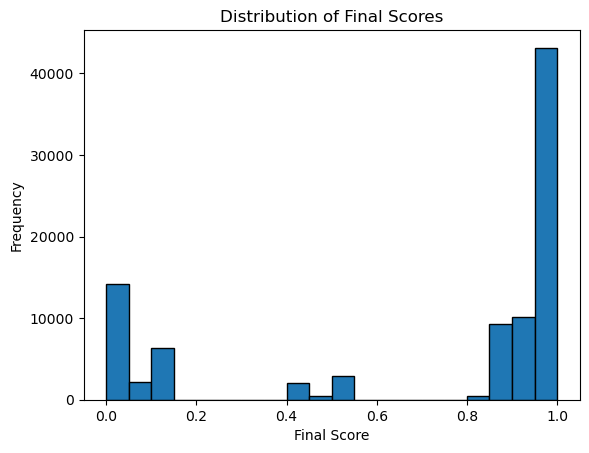

In [97]:
import matplotlib.pyplot as plt

plt.hist(resampled_train_df['Final_Score'], bins=20, edgecolor='black')
plt.xlabel('Final Score')
plt.ylabel('Frequency')
plt.title('Distribution of Final Scores')
plt.show()

## **Final Result**

In [98]:
group_one = resampled_train_df[(resampled_train_df['Final_Score'] <= 0.2)]
group_two = resampled_train_df[(resampled_train_df['Final_Score'] >= 0.4) & (resampled_train_df['Final_Score'] <= 0.6)]
group_three = resampled_train_df[(resampled_train_df['Final_Score'] >= 0.8)]

In [100]:
total = len(resampled_train_df)

print(f'{round(len(group_one) / total * 100, 2)}%')
print(f'{round(len(group_two) / total * 100, 2)}%')
print(f'{round(len(group_three) / total * 100, 2)}%')

24.9%
6.0%
69.1%


In [101]:
print(f'{round(group_one['Response'].mean() * 100, 2)}%')
print(f'{round(group_two['Response'].mean() * 100, 2)}%')
print(f'{round(group_three['Response'].mean() * 100, 2)}%')

0.31%
17.98%
70.46%


In [103]:
resampled_train_df[['Response', 'Final_Score']].corr()

,Response,Final_Score
Response,1.000000,0.626154
Final_Score,0.626154,1.000000


In [104]:
import numpy as np

group_three_sorted = group_three.sort_values(by='Final_Score')

quantiles = np.linspace(0, 1, 6)
score_quantiles = list(group_three_sorted['Final_Score'].quantile(quantiles))
score_quantiles

[0.8383348277383295,
 0.9251256945798445,
 0.9523988629193118,
 0.9621776574632616,
 0.9621776574632616,
 1.0]

In [105]:
response_means = []
for i in range(5):
    lower_bound = score_quantiles[i]
    upper_bound = score_quantiles[i + 1]

    subset = group_three_sorted[(group_three_sorted['Final_Score'] >= lower_bound) & (group_three_sorted['Final_Score'] <= upper_bound)]

    response_mean = subset['Response'].mean()
    response_means.append(response_mean)
    print(i, response_mean)

0 0.5603555832813475
1 0.6672004270082733
2 0.7562086855758342
3 0.7764499358584835
4 0.7737732267157568


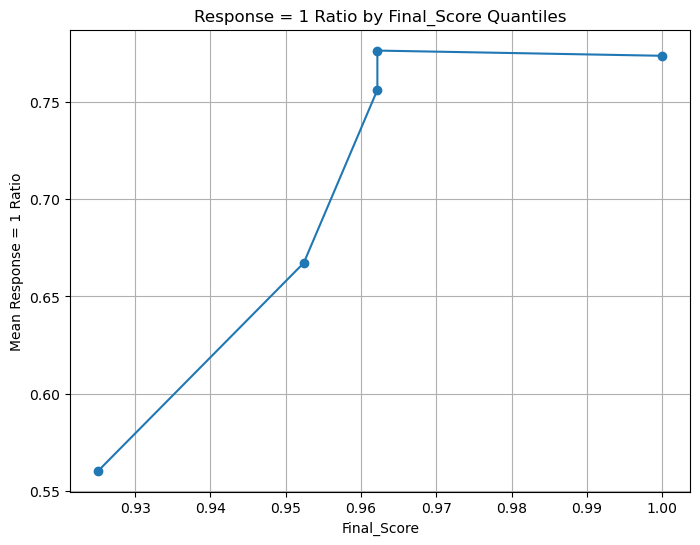

In [106]:
plt.figure(figsize=(8, 6))
plt.plot(score_quantiles[1:], response_means, marker='o')
plt.xlabel('Final_Score')
plt.ylabel('Mean Response = 1 Ratio')
plt.title('Response = 1 Ratio by Final_Score Quantiles')
plt.grid(True)
plt.show()